# Task 4 – Feature Engineering
**BCG Data Science Simulation – PowerCo Churn Analysis**

Building on the EDA from Task 3, we now engineer a richer feature set that will be fed into a churn prediction model.

Framework:
1. Remove irrelevant / redundant columns
2. Expand date columns into meaningful numeric features
3. Create new features from existing columns (price sensitivity, consumption ratios, etc.)
4. Combine price data with client data
5. Final feature set overview

## 1. Setup & Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style='whitegrid', color_codes=True)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 60)

# Load raw data
client_df = pd.read_csv('./client_data (1).csv')
price_df  = pd.read_csv('./price_data (1).csv')

print(f'Client data : {client_df.shape}')
print(f'Price data  : {price_df.shape}')

Client data : (14606, 26)
Price data  : (193002, 8)


## 2. Step 1 – Remove Irrelevant / Redundant Columns

In [3]:
# Check unique value counts for all columns
print('=== Client Data – Unique Value Counts ===')
for col in client_df.columns:
    n = client_df[col].nunique()
    print(f'  {col:40s}: {n:6,} unique values')

=== Client Data – Unique Value Counts ===
  id                                      : 14,606 unique values
  channel_sales                           :      8 unique values
  cons_12m                                : 11,065 unique values
  cons_gas_12m                            :  2,112 unique values
  cons_last_month                         :  4,751 unique values
  date_activ                              :  1,796 unique values
  date_end                                :    368 unique values
  date_modif_prod                         :  2,129 unique values
  date_renewal                            :    386 unique values
  forecast_cons_12m                       : 13,993 unique values
  forecast_cons_year                      :  4,218 unique values
  forecast_discount_energy                :     12 unique values
  forecast_meter_rent_12m                 :  3,528 unique values
  forecast_price_energy_off_peak          :    516 unique values
  forecast_price_energy_peak              :    3

In [4]:
# 'id' is a customer identifier – useful only as a join key, not a feature.
# 'forecast_cons_year' is highly correlated with 'forecast_cons_12m' 
# (annual vs 12-month forecast – essentially the same thing).

print('Correlation between forecast_cons_year and forecast_cons_12m:')
print(client_df[['forecast_cons_year', 'forecast_cons_12m']].corr())

Correlation between forecast_cons_year and forecast_cons_12m:
                    forecast_cons_year  forecast_cons_12m
forecast_cons_year            1.000000           0.647727
forecast_cons_12m             0.647727           1.000000


In [5]:
# Columns to drop:
# - 'forecast_cons_year': near-duplicate of forecast_cons_12m (same concept, annual scale)
# We keep 'id' for merging but will drop it before modelling.

cols_to_drop = ['forecast_cons_year']
client_df.drop(columns=cols_to_drop, inplace=True)
print(f'Dropped: {cols_to_drop}')
print(f'Client data shape after dropping: {client_df.shape}')

Dropped: ['forecast_cons_year']
Client data shape after dropping: (14606, 25)


## 3. Step 2 – Date Feature Extraction

In [6]:
# Convert all date columns to datetime
date_cols = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
for col in date_cols:
    client_df[col] = pd.to_datetime(client_df[col], errors='coerce')

price_df['price_date'] = pd.to_datetime(price_df['price_date'], errors='coerce')

# Reference date: use the most recent date in the dataset as 'today'
reference_date = client_df['date_end'].max()
print(f'Reference date: {reference_date.date()}')

Reference date: 2017-06-13


In [7]:
# --- Contract duration (days from activation to end) ---
client_df['contract_duration_days'] = (client_df['date_end'] - client_df['date_activ']).dt.days

# --- Days until contract renewal from reference date ---
client_df['days_to_renewal'] = (client_df['date_renewal'] - reference_date).dt.days

# --- Days since last product modification ---
client_df['days_since_modif'] = (reference_date - client_df['date_modif_prod']).dt.days

# --- Month of contract activation (seasonality signal) ---
client_df['month_activ'] = client_df['date_activ'].dt.month

# --- Month of contract end (seasonality signal) ---
client_df['month_end'] = client_df['date_end'].dt.month

# --- Year of activation ---
client_df['year_activ'] = client_df['date_activ'].dt.year

print('Date features created:')
print(client_df[['contract_duration_days', 'days_to_renewal', 'days_since_modif',
                 'month_activ', 'month_end', 'year_activ']].describe())

Date features created:
       contract_duration_days  days_to_renewal  days_since_modif  \
count            14606.000000     14606.000000      14606.000000   
mean              2007.537587      -692.709024       1622.479734   
std                604.875654       118.411002        922.472958   
min                731.000000     -1448.000000        501.000000   
25%               1461.000000      -788.000000        728.000000   
50%               1828.500000      -687.000000       1455.000000   
75%               2353.000000      -593.000000       2497.000000   
max               4795.000000      -502.000000       5149.000000   

        month_activ     month_end    year_activ  
count  14606.000000  14606.000000  14606.000000  
mean       6.558880      6.651787   2010.577502  
std        3.514151      3.498823      1.653268  
min        1.000000      1.000000   2003.000000  
25%        3.000000      3.000000   2010.000000  
50%        7.000000      7.000000   2011.000000  
75%       10.0

In [8]:
# Drop original date columns – the extracted numeric features are now our signal
client_df.drop(columns=date_cols, inplace=True)
print(f'Client data shape after date expansion: {client_df.shape}')

Client data shape after date expansion: (14606, 27)


## 4. Step 3 – Create New Features from Existing Columns

### 4a. Consumption Features

In [9]:
# --- Ratio: last month consumption vs 12-month average ---
client_df['cons_ratio_last_to_12m'] = np.where(
    client_df['cons_12m'] > 0,
    client_df['cons_last_month'] / (client_df['cons_12m'] / 12),
    0
)

# --- Ratio: gas consumption vs electricity consumption ---
client_df['gas_to_elec_ratio'] = np.where(
    client_df['cons_12m'] > 0,
    client_df['cons_gas_12m'] / client_df['cons_12m'],
    0
)

# --- Forecast vs actual consumption (over/under-usage) ---
client_df['forecast_vs_actual'] = client_df['forecast_cons_12m'] - client_df['cons_12m']

# --- Log transform of consumption (reduces skew) ---
client_df['log_cons_12m']       = np.log1p(client_df['cons_12m'])
client_df['log_cons_gas_12m']   = np.log1p(client_df['cons_gas_12m'])
client_df['log_cons_last_month']= np.log1p(client_df['cons_last_month'])

print('Consumption features created.')
client_df[['cons_ratio_last_to_12m', 'gas_to_elec_ratio', 'forecast_vs_actual',
           'log_cons_12m', 'log_cons_gas_12m']].describe()

Consumption features created.


,cons_ratio_last_to_12m,gas_to_elec_ratio,forecast_vs_actual,log_cons_12m,log_cons_gas_12m
count,14606.000000,14606.000000,1.460600e+04,14606.000000,14606.000000
mean,0.919088,11.249958,-1.573517e+05,9.725978,1.794277
std,1.026379,954.832626,5.730070e+05,2.036672,3.953703
min,0.000000,0.000000,-6.207019e+06,0.000000,0.000000
25%,0.000000,0.000000,-3.746204e+04,8.643958,0.000000
50%,0.865063,0.000000,-1.260576e+04,9.555100,0.000000
75%,1.346755,0.000000,-4.961927e+03,10.615573,0.000000
max,15.315789,104748.750000,3.534240e+03,15.641205,15.239725


### 4b. Margin Features

In [10]:
# --- Net margin per unit consumption ---
client_df['net_margin_per_unit'] = np.where(
    client_df['cons_12m'] > 0,
    client_df['net_margin'] / client_df['cons_12m'],
    0
)

# --- Gross vs net power margin difference (indicator of overhead) ---
client_df['margin_diff_gross_net'] = client_df['margin_gross_pow_ele'] - client_df['margin_net_pow_ele']

print('Margin features created.')
client_df[['net_margin_per_unit', 'margin_diff_gross_net']].describe()

Margin features created.


,net_margin_per_unit,margin_diff_gross_net
count,14606.000000,14606.000000
mean,0.010627,0.002604
std,0.063983,0.265157
min,0.000000,0.000000
25%,0.004424,0.000000
50%,0.010885,0.000000
75%,0.013135,0.000000
max,7.443333,31.340000


### 4c. Encode Categorical Features

In [11]:
# has_gas: Y/N -> 1/0
client_df['has_gas'] = (client_df['has_gas'] == 'Y').astype(int)

# channel_sales: one-hot encode
channel_dummies = pd.get_dummies(client_df['channel_sales'], prefix='channel', drop_first=True)
client_df = pd.concat([client_df.drop(columns=['channel_sales']), channel_dummies], axis=1)

# origin_up: one-hot encode
origin_dummies = pd.get_dummies(client_df['origin_up'], prefix='origin', drop_first=True)
client_df = pd.concat([client_df.drop(columns=['origin_up']), origin_dummies], axis=1)

print(f'Client data shape after encoding: {client_df.shape}')
print('Sample of new dummy columns:', [c for c in client_df.columns if c.startswith('channel') or c.startswith('origin')])

Client data shape after encoding: (14606, 45)
Sample of new dummy columns: ['channel_epumfxlbckeskwekxbiuasklxalciiuu', 'channel_ewpakwlliwisiwduibdlfmalxowmwpci', 'channel_fixdbufsefwooaasfcxdxadsiekoceaa', 'channel_foosdfpfkusacimwkcsosbicdxkicaua', 'channel_lmkebamcaaclubfxadlmueccxoimlema', 'channel_sddiedcslfslkckwlfkdpoeeailfpeds', 'channel_usilxuppasemubllopkaafesmlibmsdf', 'origin_ewxeelcelemmiwuafmddpobolfuxioce', 'origin_kamkkxfxxuwbdslkwifmmcsiusiuosws', 'origin_ldkssxwpmemidmecebumciepifcamkci', 'origin_lxidpiddsbxsbosboudacockeimpuepw', 'origin_usapbepcfoloekilkwsdiboslwaxobdp']


## 5. Step 4 – Aggregate Price Data per Customer

In [12]:
# Price data has multiple rows per customer (one per month).
# We aggregate to create per-customer price summary statistics.

price_value_cols = ['price_off_peak_var', 'price_peak_var', 'price_mid_peak_var',
                    'price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix']

# Mean price per customer
price_mean = price_df.groupby('id')[price_value_cols].mean().add_suffix('_mean')

# Max price per customer
price_max  = price_df.groupby('id')[price_value_cols].max().add_suffix('_max')

# Min price per customer
price_min  = price_df.groupby('id')[price_value_cols].min().add_suffix('_min')

# Standard deviation (price volatility – higher std = more variable pricing = potential churn trigger)
price_std  = price_df.groupby('id')[price_value_cols].std().add_suffix('_std').fillna(0)

# Combine all aggregations
price_features = pd.concat([price_mean, price_max, price_min, price_std], axis=1).reset_index()
print(f'Price features shape: {price_features.shape}')
price_features.head(3)

Price features shape: (16096, 25)


,id,price_off_peak_var_mean,price_peak_var_mean,price_mid_peak_var_mean,price_off_peak_fix_mean,price_peak_fix_mean,price_mid_peak_fix_mean,price_off_peak_var_max,price_peak_var_max,price_mid_peak_var_max,price_off_peak_fix_max,price_peak_fix_max,price_mid_peak_fix_max,price_off_peak_var_min,price_peak_var_min,price_mid_peak_var_min,price_off_peak_fix_min,price_peak_fix_min,price_mid_peak_fix_min,price_off_peak_var_std,price_peak_var_std,price_mid_peak_var_std,price_off_peak_fix_std,price_peak_fix_std,price_mid_peak_fix_std
0,0002203ffbb812588b632b9e628cc38d,0.124338,0.103794,0.07316,40.701732,24.421038,16.280694,0.128067,0.105842,0.073773,40.728885,24.43733,16.291555,0.119906,0.101673,0.070232,40.565969,24.339581,16.226389,0.003976,0.001989,0.001368,0.063415,0.038049,0.025366
1,0004351ebdd665e6ee664792efc4fd13,0.146426,0.000000,0.00000,44.385450,0.000000,0.000000,0.148405,0.000000,0.000000,44.444710,0.00000,0.000000,0.143943,0.000000,0.000000,44.266931,0.000000,0.000000,0.002197,0.000000,0.000000,0.087532,0.000000,0.000000
2,0010bcc39e42b3c2131ed2ce55246e3c,0.181558,0.000000,0.00000,45.319710,0.000000,0.000000,0.205742,0.000000,0.000000,45.944710,0.00000,0.000000,0.150837,0.000000,0.000000,44.444710,0.000000,0.000000,0.026008,0.000000,0.000000,0.772393,0.000000,0.000000


In [13]:
# --- Price Sensitivity Feature ---
# Key business question: does the DIFFERENCE between off-peak and peak prices
# matter for churn? A larger spread might indicate higher sensitivity.

# Get the most recent month's prices for each customer
price_latest = price_df.sort_values('price_date').groupby('id').last().reset_index()

# Off-peak vs peak variable price difference (most recent)
price_latest['price_sensitivity_var'] = (
    price_latest['price_off_peak_var'] - price_latest['price_peak_var']
)

# Off-peak vs peak fixed price difference (most recent)
price_latest['price_sensitivity_fix'] = (
    price_latest['price_off_peak_fix'] - price_latest['price_peak_fix']
)

# 6-month change in off-peak variable price (price trend)
price_sorted = price_df.sort_values('price_date')
price_first = price_sorted.groupby('id')['price_off_peak_var'].first()
price_last  = price_sorted.groupby('id')['price_off_peak_var'].last()
price_change = (price_last - price_first).reset_index()
price_change.columns = ['id', 'price_off_peak_var_change']

# Merge sensitivity and change into price features
price_features = price_features.merge(
    price_latest[['id', 'price_sensitivity_var', 'price_sensitivity_fix']], on='id', how='left'
)
price_features = price_features.merge(price_change, on='id', how='left')

print(f'Price features (with sensitivity) shape: {price_features.shape}')
print('New sensitivity columns:')
price_features[['price_sensitivity_var', 'price_sensitivity_fix', 'price_off_peak_var_change']].describe()

Price features (with sensitivity) shape: (16096, 28)
New sensitivity columns:


,price_sensitivity_var,price_sensitivity_fix,price_off_peak_var_change
count,16096.000000,16096.000000,16096.000000
mean,0.084058,32.861507,-0.004545
std,0.063039,14.048476,0.012778
min,0.000000,0.000000,-0.148477
25%,0.017684,16.291555,-0.008161
50%,0.079056,44.266930,-0.005610
75%,0.146264,44.444710,-0.003573
max,0.276238,59.444710,0.168958


## 6. Step 5 – Merge Datasets

In [14]:
# Merge client features with aggregated price features on 'id'
full_df = client_df.merge(price_features, on='id', how='left')

print(f'Final merged dataset shape: {full_df.shape}')
print(f'Rows matched: {full_df["price_sensitivity_var"].notna().sum()} / {len(full_df)}')

Final merged dataset shape: (14606, 72)
Rows matched: 14606 / 14606


In [15]:
# Check for any new nulls after merge
null_counts = full_df.isnull().sum()
null_cols = null_counts[null_counts > 0]
if null_cols.empty:
    print('No missing values in final dataset ✓')
else:
    print('Columns with missing values after merge:')
    print(null_cols)

No missing values in final dataset ✓


In [16]:
# Fill any remaining nulls from price join with 0 (customers with no price data)
full_df.fillna(0, inplace=True)
print(f'Missing values after fill: {full_df.isnull().sum().sum()}')

Missing values after fill: 0


## 7. Validation – Feature Distributions vs Churn

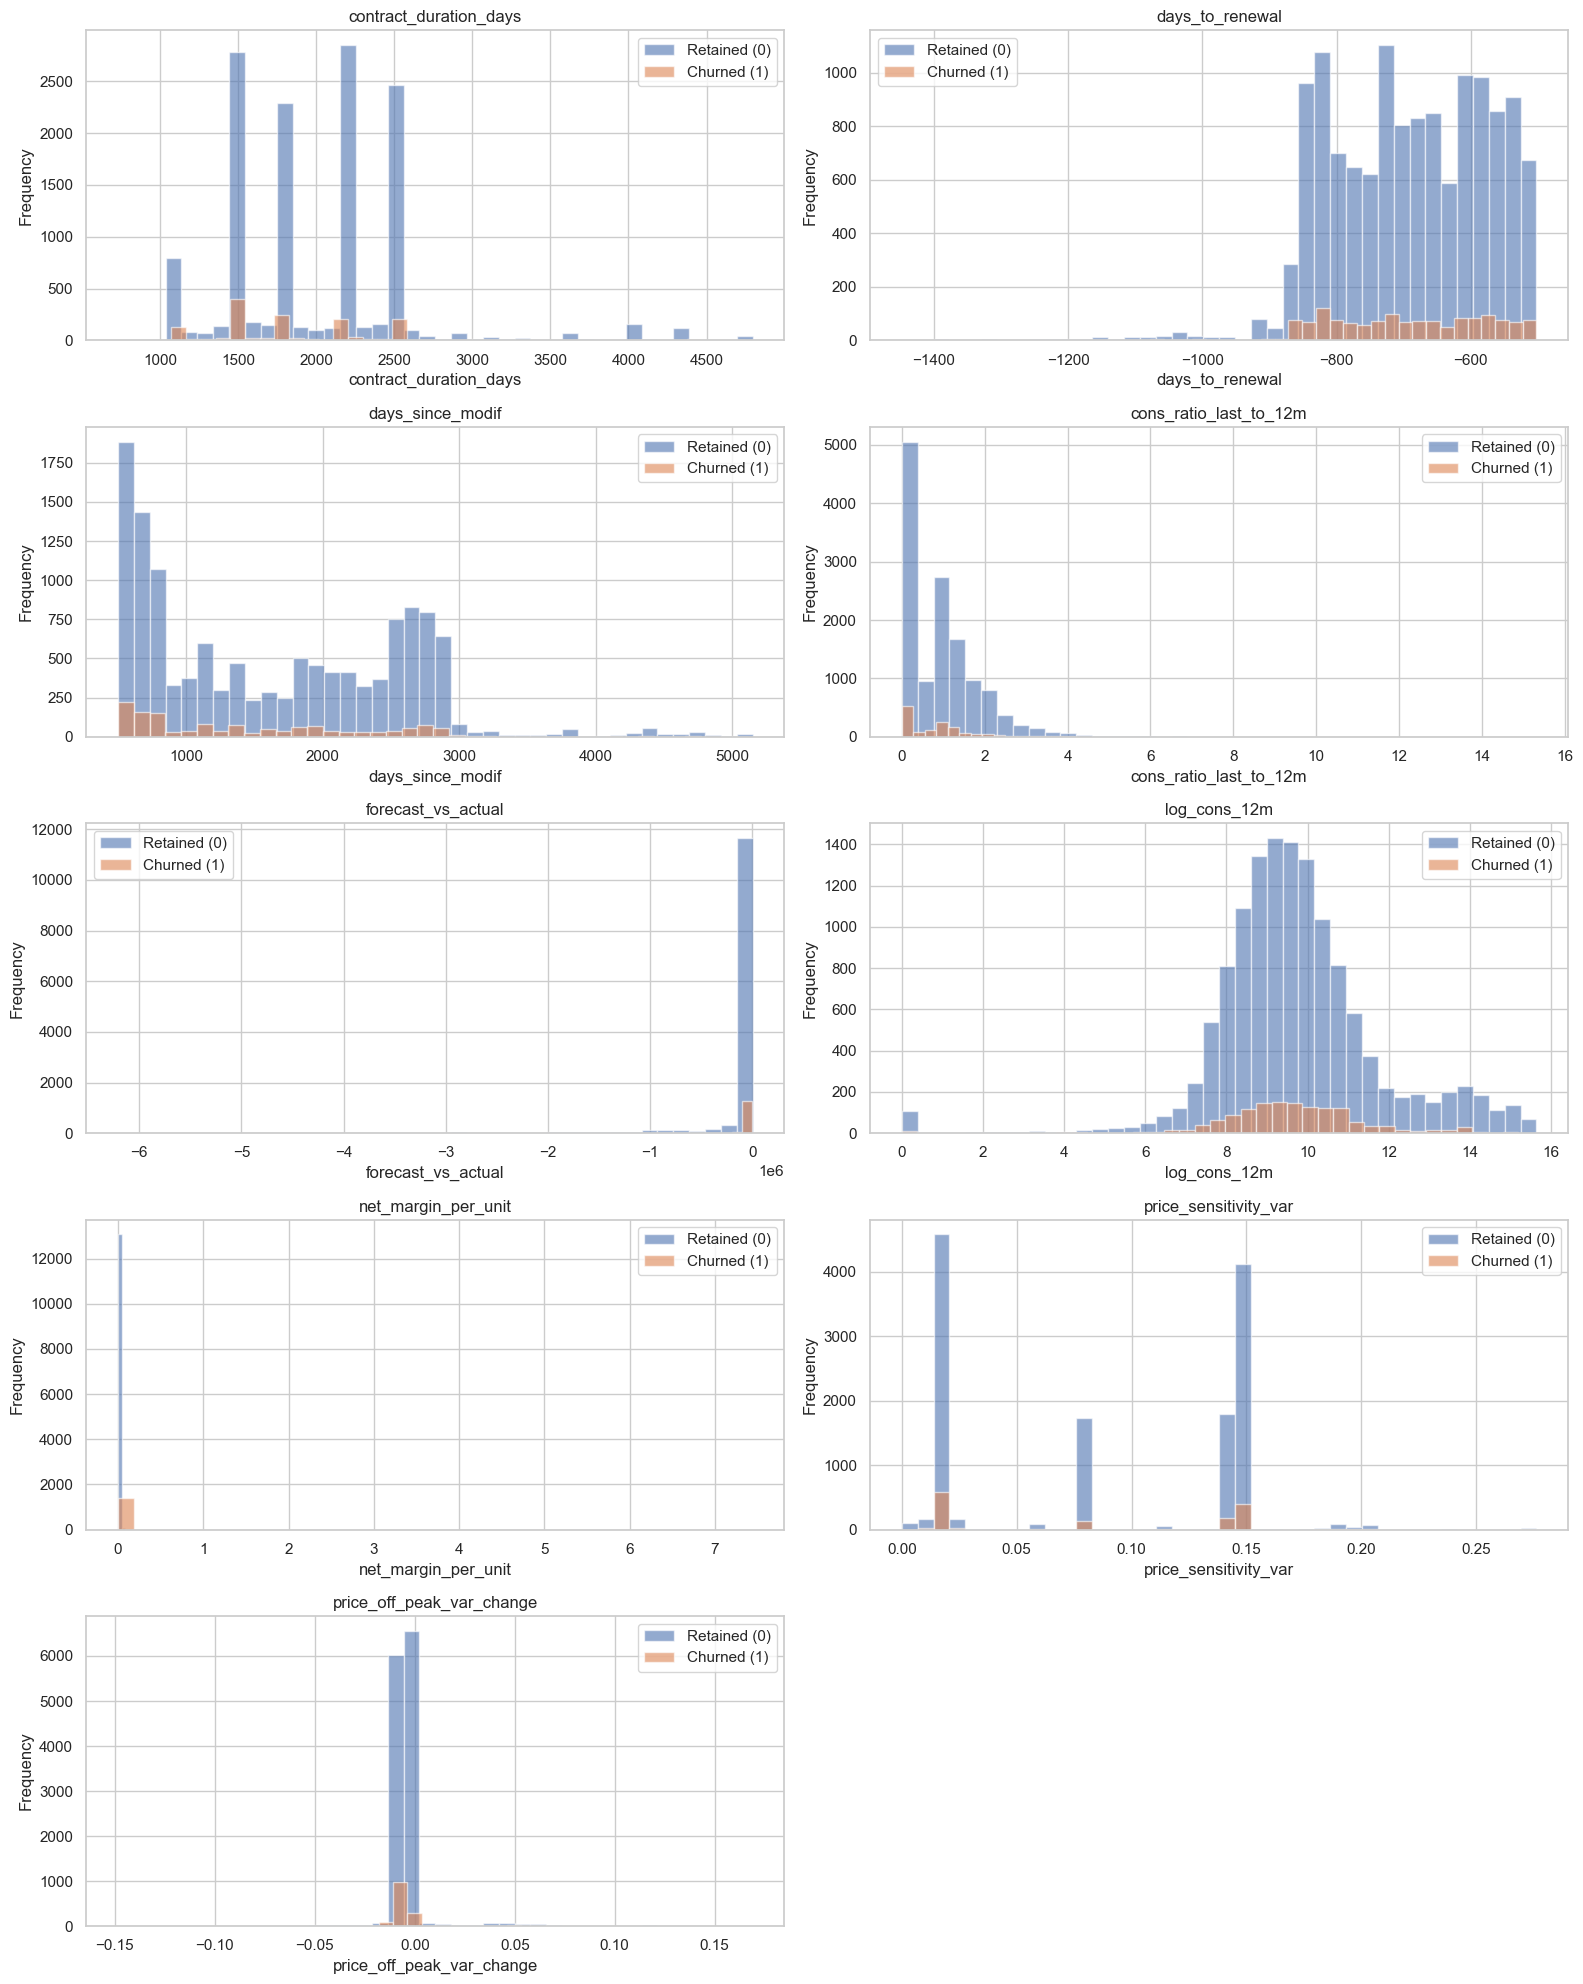

In [17]:
def plot_feature_vs_churn(df, features, n_cols=2):
    n_rows = int(np.ceil(len(features) / n_cols))
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
    axs = axs.flatten()
    for i, feat in enumerate(features):
        df.groupby('churn')[feat].plot(kind='hist', bins=40, alpha=0.6, ax=axs[i], legend=True)
        axs[i].set_title(feat)
        axs[i].set_xlabel(feat)
        axs[i].legend(['Retained (0)', 'Churned (1)'])
    # Hide unused axes
    for j in range(i+1, len(axs)):
        axs[j].set_visible(False)
    plt.tight_layout()
    plt.show()

# New engineered features
new_features = [
    'contract_duration_days', 'days_to_renewal', 'days_since_modif',
    'cons_ratio_last_to_12m', 'forecast_vs_actual', 'log_cons_12m',
    'net_margin_per_unit', 'price_sensitivity_var', 'price_off_peak_var_change'
]
plot_feature_vs_churn(full_df, new_features)

## 8. Correlation of New Features with Churn

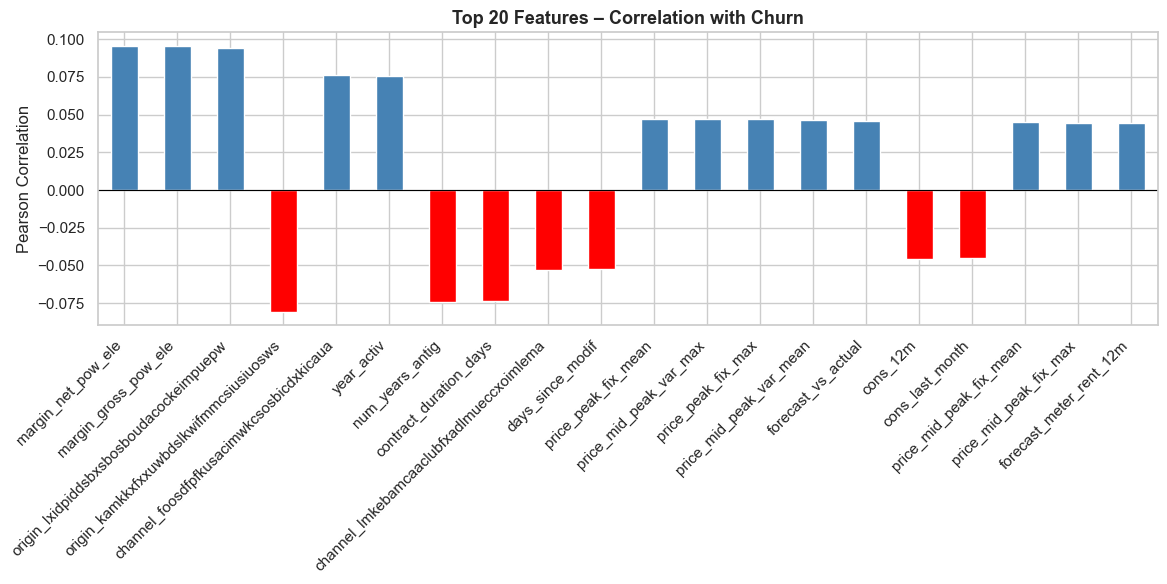

In [18]:
numeric_final = full_df.select_dtypes(include=[np.number])
churn_corr = numeric_final.corr()['churn'].drop('churn').sort_values(key=abs, ascending=False)

# Show top 20 features correlated with churn
top_corr = churn_corr.head(20)

plt.figure(figsize=(12, 6))
top_corr.plot(kind='bar', color=['red' if x < 0 else 'steelblue' for x in top_corr])
plt.title('Top 20 Features – Correlation with Churn', fontsize=13, fontweight='bold')
plt.ylabel('Pearson Correlation')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 9. Final Dataset Overview

In [19]:
# Drop 'id' as it is not a predictive feature
model_df = full_df.drop(columns=['id'])

print(f'Final model dataset shape: {model_df.shape}')
print(f'Target distribution:\n{model_df["churn"].value_counts()}')
print(f'\nChurn rate: {model_df["churn"].mean():.2%}')
print(f'\nAll columns ({len(model_df.columns)}):')
for col in sorted(model_df.columns):
    print(f'  {col}')

Final model dataset shape: (14606, 71)
Target distribution:
0    13187
1     1419
Name: churn, dtype: int64

Churn rate: 9.72%

All columns (71):
  channel_epumfxlbckeskwekxbiuasklxalciiuu
  channel_ewpakwlliwisiwduibdlfmalxowmwpci
  channel_fixdbufsefwooaasfcxdxadsiekoceaa
  channel_foosdfpfkusacimwkcsosbicdxkicaua
  channel_lmkebamcaaclubfxadlmueccxoimlema
  channel_sddiedcslfslkckwlfkdpoeeailfpeds
  channel_usilxuppasemubllopkaafesmlibmsdf
  churn
  cons_12m
  cons_gas_12m
  cons_last_month
  cons_ratio_last_to_12m
  contract_duration_days
  days_since_modif
  days_to_renewal
  forecast_cons_12m
  forecast_discount_energy
  forecast_meter_rent_12m
  forecast_price_energy_off_peak
  forecast_price_energy_peak
  forecast_price_pow_off_peak
  forecast_vs_actual
  gas_to_elec_ratio
  has_gas
  imp_cons
  log_cons_12m
  log_cons_gas_12m
  log_cons_last_month
  margin_diff_gross_net
  margin_gross_pow_ele
  margin_net_pow_ele
  month_activ
  month_end
  nb_prod_act
  net_margin
  net_marg

In [20]:
# Save the engineered dataset for modelling
model_df.to_csv('./engineered_features.csv', index=False)
print('Saved: engineered_features.csv')

Saved: engineered_features.csv


## 10. Summary of Feature Engineering

| Category | Features Created | Rationale |
|---|---|---|
| **Removed** | `forecast_cons_year` | Near-duplicate of `forecast_cons_12m` |
| **Date → Numeric** | `contract_duration_days`, `days_to_renewal`, `days_since_modif`, `month_activ`, `month_end`, `year_activ` | Raw dates are not model-ready; numeric representations capture time-based patterns |
| **Consumption ratios** | `cons_ratio_last_to_12m`, `gas_to_elec_ratio`, `forecast_vs_actual` | Capture behavioural changes and forecast accuracy |
| **Log transforms** | `log_cons_12m`, `log_cons_gas_12m`, `log_cons_last_month` | Reduce extreme skew in consumption columns |
| **Margin per unit** | `net_margin_per_unit`, `margin_diff_gross_net` | Profitability relative to usage |
| **Encoding** | `has_gas` (0/1), `channel_*` dummies, `origin_*` dummies | Makes categorical features model-compatible |
| **Price aggregation** | Mean / max / min / std per customer | Summarise 12 months of pricing into per-customer signals |
| **Price sensitivity** | `price_sensitivity_var`, `price_sensitivity_fix`, `price_off_peak_var_change` | Directly measures the off-peak vs peak gap and price trends – key hypothesis for churn |
| **Merged datasets** | `full_df` (client + price) joined on `id` | Single modelling-ready dataframe |

**Ready for modelling:** A Random Forest classifier would be a suitable first model, as it handles mixed feature types, is robust to outliers, and provides feature importance rankings to further validate our engineered features.